In [5]:
# Load the first time series response = 
from io import BytesIO
import numpy as np
import requests

stationarity_ts1 = np.load("2.1.ts1.npy")
print(len(stationarity_ts1))

stationarity_ts2 = np.load("2.1.ts2.npy")
print(len(stationarity_ts2))

100
100


Text(0.5, 1.0, 'stationarity_ts2')

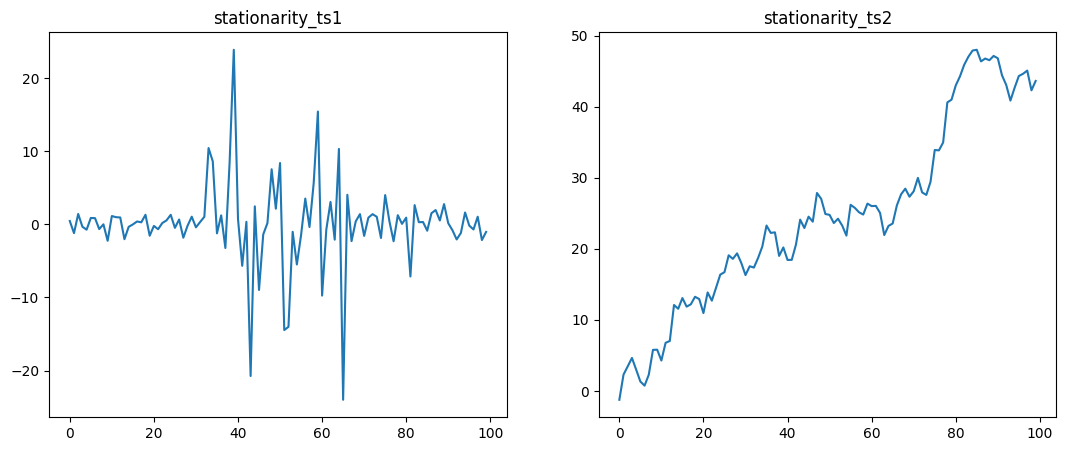

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.title('stationarity_ts1')
plt.plot(stationarity_ts1)
plt.subplot(1,2,2)
plt.plot(stationarity_ts2)
plt.title('stationarity_ts2')

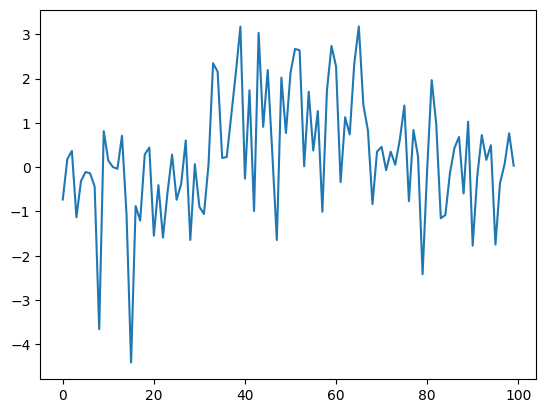

In [44]:
# Превратим мултипликативный ряд в логарифмированный
ts1_log = np.log(np.abs(stationarity_ts1)+0.01)
plt.plot(ts1_log)

`ts1` точно мултипликативный ряд.

Среднее ряда около нуля, но дисперсия разная. Даже при логарифмировании явно есть тренд и дисперсия разная.

Это не стационарный ряд.


`ts2` точно аддитивный

Похож график на броуновский шум без сезонности.

У графика есть тренд. Это не стационарный ряд.


TS1:
Chunk means: [-0.6004797619369795, 0.621333996974693, 1.0705744751963477, -0.02005447929285709]
Chunk stds:  [1.2083945280916548, 1.3957937938271718, 1.1500896072305733, 1.0258024183682066]
ADF stat: -1.592, p-value: 0.4874
Non-stationary

TS2:
Chunk means: [8.069698643618052, 20.87119964164015, 25.78207569568579, 43.39785742119324]
Chunk stds:  [5.089808333916263, 3.1655921436999153, 2.153323242667177, 3.989941288028241]
ADF stat: -1.322, p-value: 0.6189
Non-stationary


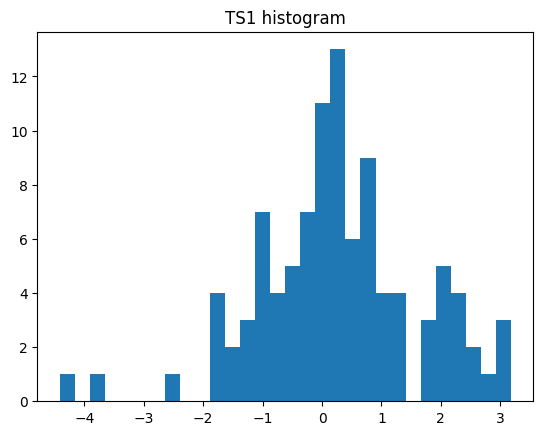

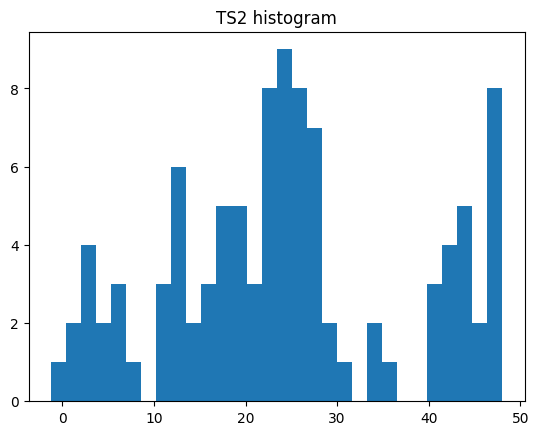

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

def check_ts(ts, name):
    print(f"\n{name}:")
    
    # Создадим чанки
    chunks = np.array_split(ts, 4)
    means = [np.mean(c) for c in chunks]
    stds = [np.std(c) for c in chunks]
    print(f"Chunk means: {means}")
    print(f"Chunk stds:  {stds}")
    
    # Histogram
    plt.figure()
    plt.hist(ts, bins=30)
    plt.title(f"{name} histogram")
    
    # ADF test
    stat, p = adfuller(ts)[:2]
    print(f"ADF stat: {stat:.3f}, p-value: {p:.4f}")
    print("Stationary" if p < 0.05 else "Non-stationary")

check_ts(ts1_log, "TS1")
check_ts(stationarity_ts2, "TS2")
plt.show()

И по статистике видно, что оба ряда не стационарные.

Гистограммы далеки от равномерно и нормально распределенных

Расширенный тест дики-фулера показал большие p-value, что тоже говорит о нестационарности

Попробуем сделать ряды стационарными

Text(0.5, 1.0, 'Ts2 diff')

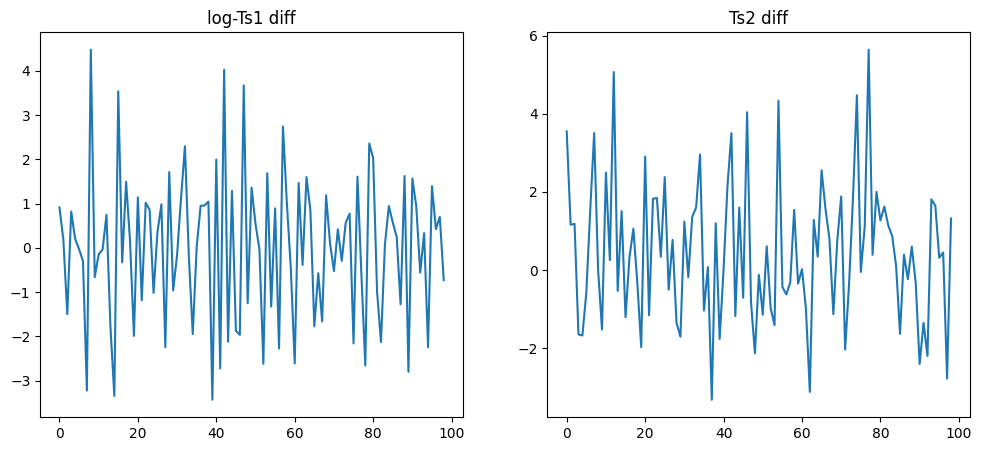

In [48]:
ts1_diff = np.diff(ts1_log)
ts2_diff = np.diff(stationarity_ts2)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ts1_diff)
plt.title("log-Ts1 diff")

plt.subplot(1,2,2)
plt.plot(ts2_diff)
plt.title("Ts2 diff")


Теперь ряды выглядят как стационарные! И статистика подтвержтает это!


ts1 diff:
Chunk means: [-0.000177353416882573, 0.11464151281921349, -0.029516998672382454, -0.05664542221267679]
Chunk stds:  [1.7208828426002283, 1.9258073964530262, 1.3853156903549824, 1.51544720679714]
ADF stat: -7.937, p-value: 0.0000
Stationary

log ts2 diff:
Chunk means: [0.7179918646246207, 0.32248804287780886, 0.36498773207111085, 0.4048850722454083]
Chunk stds:  [1.8217996590108796, 1.8204757962759117, 1.7696936444885087, 1.720575115329115]
ADF stat: -10.280, p-value: 0.0000
Stationary


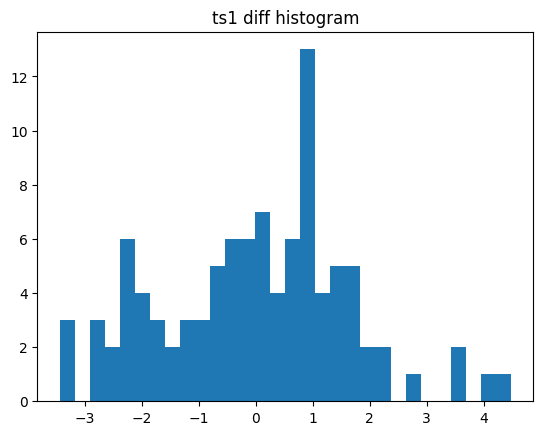

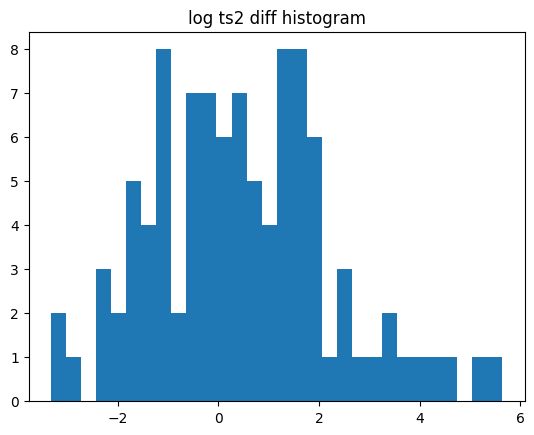

In [50]:
check_ts(ts1_diff,"ts1 diff")
check_ts(ts2_diff,"log ts2 diff")